# Analyse dataset 2

Contient les positions géographiques des Wind Farms.

## Import des modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_parquet('../data/dataset_2.parquet')

print(df)

                          site_name  latitude  longitude
0       Nobelwind Offshore Windpark   51.6631     2.8339
1                Rentel Offshore WP   51.5910     2.9440
2               Norther Offshore WP   51.5280     3.0320
3                     Northwester 2   51.6875     2.7488
4               Mermaid Offshore WP   51.6300     2.8597
5               Seastar Offshore WP   51.7190     2.7400
6                   Belwind Phase 1   51.6600     2.8000
7                         Northwind   51.6186     2.8998
8  Thorntonbank - C-Power - Area NE   51.5560     2.9689
9  Thorntonbank - C-Power - Area SW   51.5400     2.9210


## Carte des Wind Farms

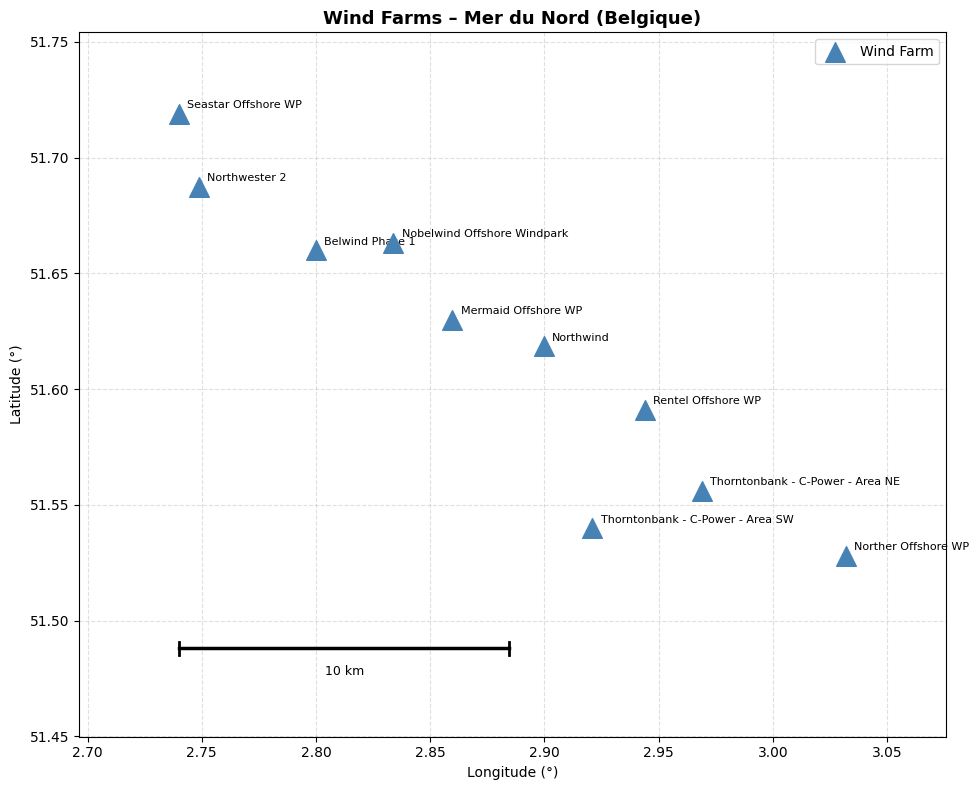

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(df['longitude'], df['latitude'], s=200, color='steelblue',
           zorder=5, marker='^', label='Wind Farm')

for _, row in df.iterrows():
    ax.annotate(row['site_name'],
                xy=(row['longitude'], row['latitude']),
                xytext=(6, 4), textcoords='offset points',
                fontsize=8)

ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
ax.set_title('Wind Farms – Mer du Nord (Belgique)', fontsize=13, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='upper right')
ax.margins(0.15)

# Échelle de distance : 10 km converti en degrés de longitude
lat_rad = np.radians(df['latitude'].mean())
scale_deg = 10 / (111.32 * np.cos(lat_rad))

x0 = df['longitude'].min()
y0 = df['latitude'].min() - 0.04

ax.plot([x0, x0 + scale_deg], [y0, y0], 'k-', linewidth=2.5)
ax.plot([x0, x0], [y0 - 0.003, y0 + 0.003], 'k-', linewidth=2)
ax.plot([x0 + scale_deg, x0 + scale_deg], [y0 - 0.003, y0 + 0.003], 'k-', linewidth=2)
ax.text(x0 + scale_deg / 2, y0 - 0.007, '10 km', ha='center', va='top', fontsize=9)

plt.tight_layout()
plt.show()